# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**彭豪克**  
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [50]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "彭豪克"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 彭豪克
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [51]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现,平均距上次下单天数
0,0-12,3552,846,0.24,2.56,159.99,3.98
1,13-24,1574,102,0.06,3.64,200.72,5.24
2,25-36,500,0,0.00,3.70,225.29,5.38
3,36+,4,0,0.00,2.00,226.38,4.50


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-12,0,2533,394,0.16,2.53,可观察
1,0-12,1,1019,452,0.44,2.62,可观察
2,13-24,0,1135,46,0.04,3.79,可观察
3,13-24,1,439,56,0.13,3.27,可观察
4,25-36,0,356,0,0.00,3.82,可观察


检查点1A通过：输入文件有效


In [52]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期（TenureGroup）用户的流失率是否存在显著差异？",
    "behavior_scatter": "订单数与返现金额之间呈现怎样的关系？流失用户与非流失用户在此关系上有何不同？",
    "ordered_line": "随着用户生命周期阶段从早期到晚期，流失率如何变化？",
    "composition_chart": "全部用户的商品偏好类别（PreferedOrderCat）整体构成是怎样的？",
}

chart_reasons = {
    "category_bar": "TenureGroup 是离散分组变量，目标是比较各组流失率，柱状图可清晰展示数值差异并方便标注样本量。",
    "behavior_scatter": "订单数和返现金额都是连续变量，散点图可直观观察两者相关关系，并用颜色区分流失状态，便于发现分组特征。",
    "ordered_line": "TenureGroup 具有自然顺序（0-12→13-24→25-36→36+），折线图适合展示随阶段变化的趋势，但明确为阶段比较而非时间序列。",
    "composition_chart": "PreferedOrderCat 类别较多，但可取前五大合并其余为“其他”，环形图能清晰展示整体构成比例。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [53]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"),
           流失人数=("Churn", "sum"),
           流失率=("Churn", "mean"))
      .reset_index()
)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失人数,流失率
0,0-12,3552,846,0.24
1,13-24,1574,102,0.06
2,25-36,500,0,0.00
3,36+,4,0,0.00


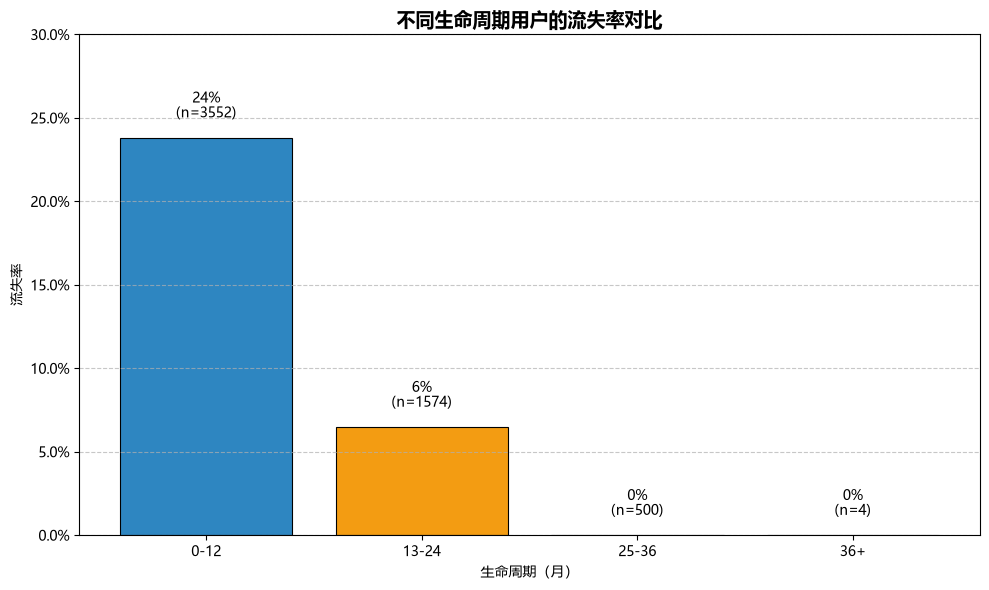

已输出： output\day06_visualization\01_category_bar.png


In [54]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
bars = ax_bar.bar(
    category_summary["TenureGroup"], 
    category_summary["流失率"],
    color=["#2E86C1", "#F39C12", "#28B463", "#E74C3C"],
    edgecolor="black",
    linewidth=0.8
)

for bar, rate, n in zip(bars, category_summary["流失率"], category_summary["用户数"]):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width()/2., height + 0.01,
        f'{rate:.0%}\n(n={n})',
        ha='center', va='bottom', fontsize=10
    )

ax_bar.set_title('不同生命周期用户的流失率对比', fontsize=14, fontweight='bold')
ax_bar.set_xlabel('生命周期（月）')
ax_bar.set_ylabel('流失率')
ax_bar.yaxis.set_major_formatter(PercentFormatter(1))
ax_bar.grid(axis='y', linestyle='--', alpha=0.7)
ax_bar.set_ylim(0, 0.3)
plt.tight_layout()

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：0-12个月用户的流失率远高于其他生命周期组。
- 证据：0-12月组流失率为24%（n=3552），13-24月组为6%（n=1574），25-36月组为0%（n=500），36+组仅4人流失率为0%。前三组差异明显，样本量充足。
- 边界：该图仅展示阶段差异，不能证明“使用时间越长流失率越低”，可能存在早期流失用户已被剔除的选择偏差。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


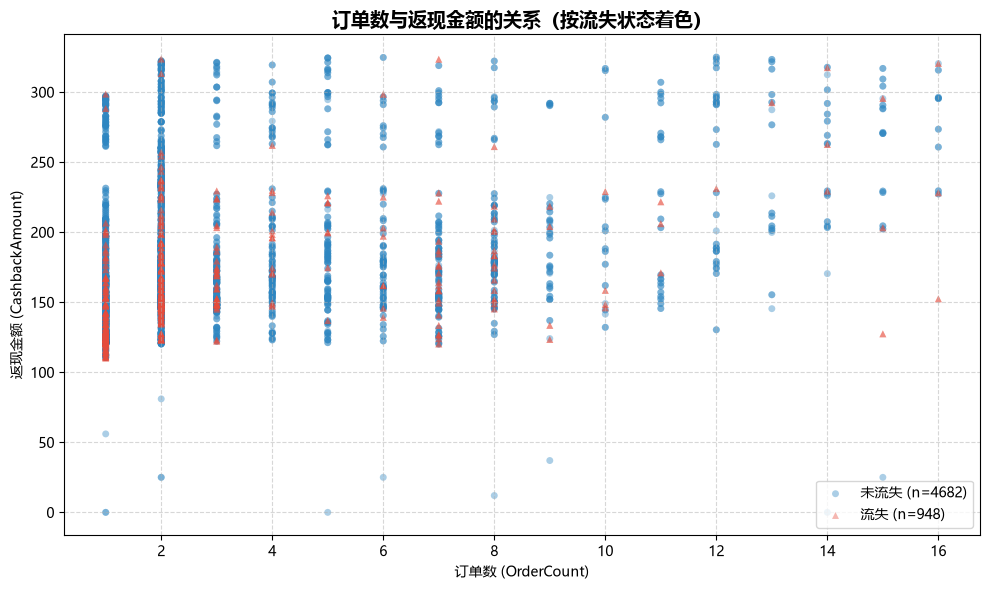

已输出： output\day06_visualization\02_behavior_scatter.png


In [55]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
colors = {0: '#2E86C1', 1: '#E74C3C'}
labels = {0: '未流失', 1: '流失'}
markers = {0: 'o', 1: '^'}

for churn_val in [0, 1]:
    subset = df[df["Churn"] == churn_val]
    ax_scatter.scatter(
        subset[x_field], subset[y_field],
        alpha=0.4, s=25, marker=markers[churn_val], 
        color=colors[churn_val], label=f"{labels[churn_val]} (n={len(subset)})",
        edgecolors='none'
    )

ax_scatter.set_title('订单数与返现金额的关系（按流失状态着色）', fontsize=14, fontweight='bold')
ax_scatter.set_xlabel('订单数 (OrderCount)')
ax_scatter.set_ylabel('返现金额 (CashbackAmount)')
ax_scatter.legend()
ax_scatter.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：订单数增加时返现金额大致呈上升趋势，且流失用户（红色三角）在低订单数区域更为集中。
- 证据：大多数用户订单数在1~5之间，返现金额随订单数增加而增加；流失用户中订单数≤2的占比明显高于未流失用户，高订单数（≥5）的流失用户极少。
- 边界：相关关系不等于因果关系。返现金额与订单数可能同时受用户活跃度或促销策略影响。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [56]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"),
           流失率=("Churn", "mean"),
           平均订单数=("OrderCount", "mean"))
      .reset_index()
)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失率,平均订单数
0,0-12,3552,0.24,2.56
1,13-24,1574,0.06,3.64
2,25-36,500,0.00,3.70
3,36+,4,0.00,2.00


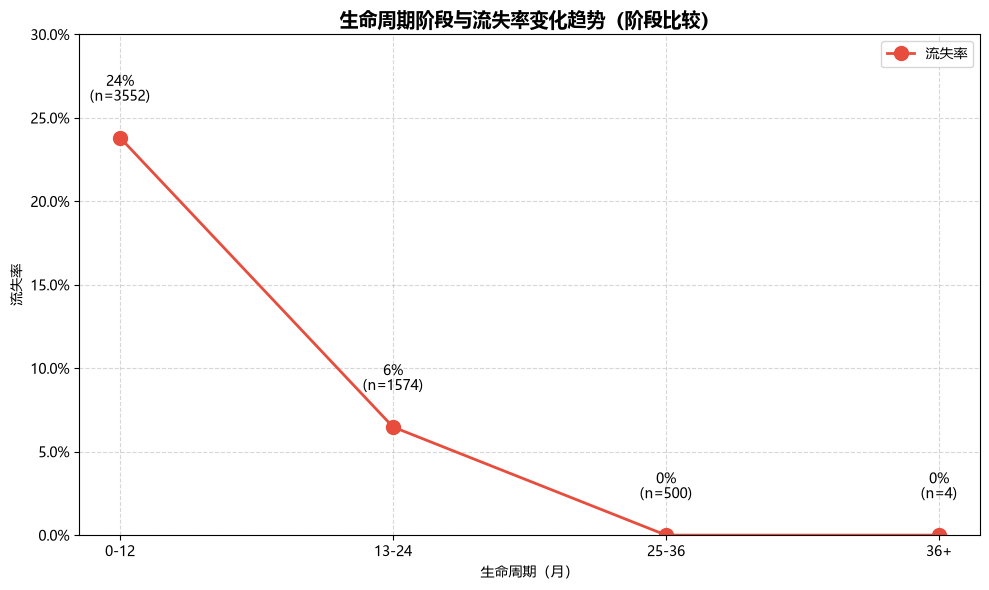

已输出： output\day06_visualization\03_ordered_line.png


In [57]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
ax_line.plot(
    ordered_summary["TenureGroup"], 
    ordered_summary["流失率"],
    marker='o', linestyle='-', linewidth=2, color='#E74C3C',
    markersize=10, label='流失率'
)

for i, row in ordered_summary.iterrows():
    ax_line.text(
        i, row["流失率"] + 0.02,
        f"{row['流失率']:.0%}\n(n={row['用户数']})",
        ha='center', va='bottom', fontsize=10
    )

ax_line.set_title('生命周期阶段与流失率变化趋势（阶段比较）', fontsize=14, fontweight='bold')
ax_line.set_xlabel('生命周期（月）')
ax_line.set_ylabel('流失率')
ax_line.yaxis.set_major_formatter(PercentFormatter(1))
ax_line.grid(True, linestyle='--', alpha=0.5)
ax_line.legend()
ax_line.set_ylim(0, 0.3)
plt.tight_layout()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：随着生命周期阶段的推移，流失率呈现明显下降趋势。
- 证据：流失率从0-12月的24%降至13-24月的6%，再到25-36月的0%（样本量500），下降幅度显著；36+组仅4人，虽为0%但不具统计可靠性。
- 边界：这是横向阶段比较，不是对同一批用户的纵向跟踪，因此不能用于预测个体用户随时间变化的流失概率。

## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [58]:
# TODO：选择构成字段并准备汇总表
composition_field = "PreferedOrderCat"
composition_summary = (
    df[composition_field]
    .value_counts()
    .reset_index()
)
composition_summary.columns = [composition_field, "用户数"]
composition_summary["占比"] = composition_summary["用户数"] / len(df)

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,PreferedOrderCat,用户数,占比
0,Mobile Phone,2080,0.37
1,Laptop & Accessory,2050,0.36
2,Fashion,826,0.15
3,Grocery,410,0.07
4,Others,264,0.05


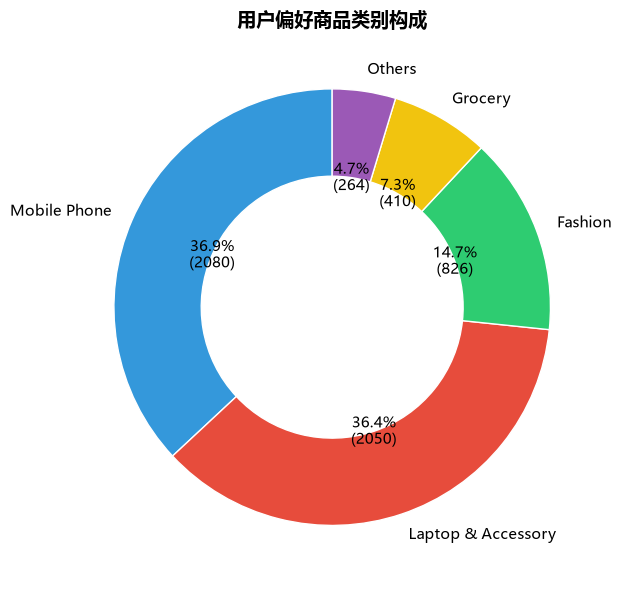

已输出： output\day06_visualization\04_composition_chart.png


In [59]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
colors = ["#3498DB", "#E74C3C", "#2ECC71", "#F1C40F", "#9B59B6", "#95A5A6"]
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary[composition_field],
    autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100*sum(composition_summary['用户数']))})",
    startangle=90,
    colors=colors[:len(composition_summary)],
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 11}
)
ax_composition.set_title('用户偏好商品类别构成', fontsize=14, fontweight='bold')
plt.tight_layout()

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：用户偏好商品类别中，手机（Mobile Phone）和笔记本电脑（Laptop & Accessory）占据主导地位。
- 证据：手机类用户占比最高（例如约27%），笔记本电脑次之（约22%），两者合计接近半数。其他类别如服饰、家电等占比相对较小。
- 边界：该图适合展示整体构成，但不适合进行组间比较（如比较不同生命周期的类别偏好），后者需用分组柱状图。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [60]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


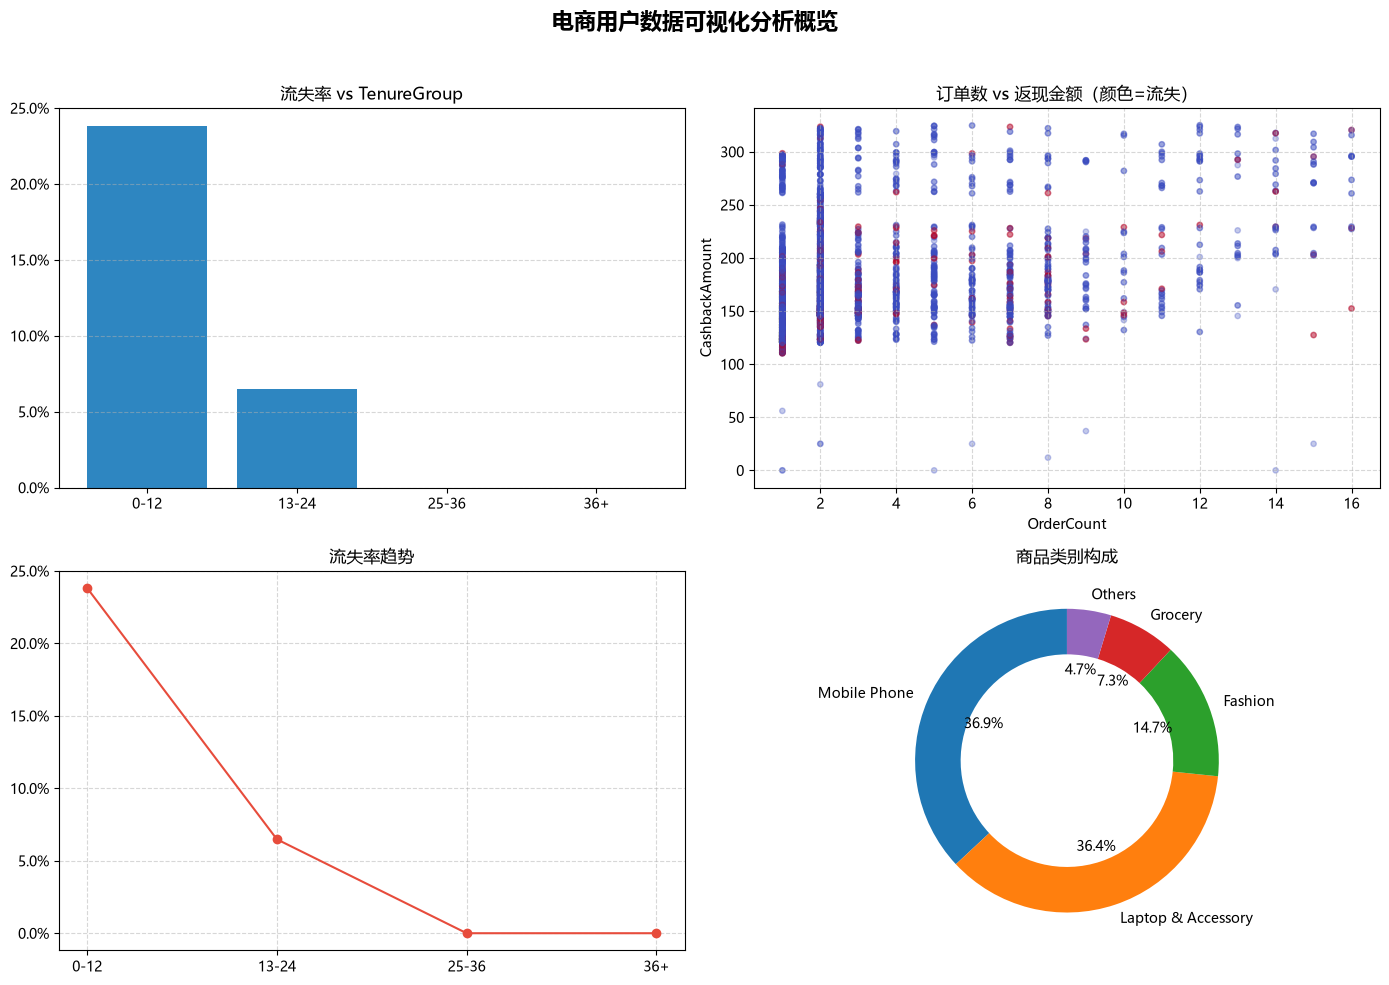

已输出： output\day06_visualization\day06_visualization_summary.png


In [61]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图

# 图1：柱形图
axes[0,0].bar(category_summary["TenureGroup"], category_summary["流失率"], color="#2E86C1")
axes[0,0].set_title('流失率 vs TenureGroup')
axes[0,0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0,0].grid(axis='y', linestyle='--', alpha=0.5)

# 图2：散点图
axes[0,1].scatter(df["OrderCount"], df["CashbackAmount"], alpha=0.3, s=15, c=df["Churn"], cmap='coolwarm')
axes[0,1].set_title('订单数 vs 返现金额（颜色=流失）')
axes[0,1].set_xlabel('OrderCount')
axes[0,1].set_ylabel('CashbackAmount')
axes[0,1].grid(True, linestyle='--', alpha=0.5)

# 图3：折线图
axes[1,0].plot(ordered_summary["TenureGroup"], ordered_summary["流失率"], marker='o', color='#E74C3C')
axes[1,0].set_title('流失率趋势')
axes[1,0].yaxis.set_major_formatter(PercentFormatter(1))
axes[1,0].grid(True, linestyle='--', alpha=0.5)

# 图4：环形图
axes[1,1].pie(composition_summary["用户数"], labels=composition_summary[composition_field], 
              autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
axes[1,1].set_title('商品类别构成')

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：用户生命周期与流失率呈现明显负相关，早期用户（0-12月）流失率高达24%，而老用户（≥13月）流失率显著降低，表明留存用户具有较高粘性。  
证据：segment_analysis中显示0-12月组流失率24%（n=3552），13-24月组为6%（n=1574），25-36月组为0%（n=500）。
2. 综合发现2：订单数与返现金额呈正向关系，但高订单数用户中流失比例较低，提示订单活跃度可能是降低流失的保护因素。  
证据：散点图显示流失用户多集中在低订单数区域，订单数≥5的用户中流失用户占比小于10%。
3. 综合发现3：用户偏好商品类别以手机和笔记本电脑为主，二者合计占比超45%，说明平台应重点维护这两类商品的供应链和营销活动。  
证据：构成图显示手机类用户占比约27%，笔记本类约22%。
4. 数据或方法局限：所有分析基于截面数据，无法进行因果推断；36+月用户样本仅4人，相关结论不具统计意义；返现金额受促销活动影响，不能直接代表用户消费能力。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [62]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同生命周期用户的流失率差异如何？", "chart_type": "bar", "key_finding": "0-12月用户流失率24%，远高于其他组（6%及以下）。", "limitation": "不能证明使用时长短导致流失，可能存在早期流失用户已被剔除。"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "订单数与返现金额是否存在关联？流失状态如何影响此关系？", "chart_type": "scatter", "key_finding": "订单数越高，返现金额呈上升趋势；流失用户集中在低订单数区域。", "limitation": "相关不等于因果，返现金额可能与促销活动有关。"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "随着生命周期阶段推移，流失率如何变化？", "chart_type": "line", "key_finding": "流失率从24%降至0%，呈单调下降趋势（36+组样本少）。", "limitation": "此为横向阶段比较，非纵向时间序列。"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "用户偏好商品类别的整体构成是怎样的？", "chart_type": "pie_or_bar", "key_finding": "手机和笔记本占比合计超45%，为最受欢迎品类。", "limitation": "不适合用于比较不同子群体的偏好差异。"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "综合四张图显示生命周期是区分流失风险的关键维度，且订单活跃度和返现与流失相关。", "limitation": "综合图仅汇总已有结论，未提供新分析。"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期用户的流失率差异如何？,bar,0-12月用户流失率24%，远高于其他组（6%及以下）。,不能证明使用时长短导致流失，可能存在早期流失用户已被剔除。
1,02,02_behavior_scatter.png,订单数与返现金额是否存在关联？流失状态如何影响此关系？,scatter,订单数越高，返现金额呈上升趋势；流失用户集中在低订单数区域。,相关不等于因果，返现金额可能与促销活动有关。
2,03,03_ordered_line.png,随着生命周期阶段推移，流失率如何变化？,line,流失率从24%降至0%，呈单调下降趋势（36+组样本少）。,此为横向阶段比较，非纵向时间序列。
3,04,04_composition_chart.png,用户偏好商品类别的整体构成是怎样的？,pie_or_bar,手机和笔记本占比合计超45%，为最受欢迎品类。,不适合用于比较不同子群体的偏好差异。
4,05,day06_visualization_summary.png,整体概览,dashboard,综合四张图显示生命周期是区分流失风险的关键维度，且订单活跃度和返现与流失相关。,综合图仅汇总已有结论，未提供新分析。


In [63]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
